In [ ]:
#spektrální analýza
import numpy as np; import matplotlib.pyplot as plt; from scipy.signal import stft, find_peaks
f_v = 500; t = np.linspace(0,20,f_v*10,endpoint=False)
ecg_signal = 0.3*np.sin(2*np.pi*1*t)
r_peaks = (np.sin(2*np.pi*50*t)>0.95).astype(float)
r_peaks[r_peaks>0]=1
ecg_signal+=r_peaks
f,time,Zxx = stft(ecg_signal,fs=f_v,nperseg=256) #fArray of sample frequencies,Array of segment times. STFT of x. By default, the last axis of Zxx corresponds to the segment times.
energy=np.sum(np.abs(Zxx),axis=0)
peaks, _ = find_peaks(energy,height=np.max(energy)*0.5) #r-vrcholy jsou výrazné
#původní EKG signál
plt.figure(figsize=(12,8))
plt.subplot(3,1,1)
plt.plot(t, ecg_signal, label='Simulovaný EKG signál')
plt.scatter(t[peaks],ecg_signal[peaks*f_v//len(time)],color="red",label='R-vrcholy',zorder=5)
plt.xlabel('Čas [s]');plt.ylabel('Amplituda');plt.title('Simulovaný EKG signál s R-vrcholy');plt.legend();plt.grid()
#STFT
plt.subplot(3, 1, 2); plt.pcolormesh(time, f, np.abs(Zxx), shading='gouraud')
plt.colorbar(label='Magnituda STFT');plt.ylabel('Frekvence [Hz]');plt.title('Spektrogram (STFT) EKG signálu')
#energie ve frekvenčních pásmech
plt.subplot(3, 1, 3)
plt.plot(time, energy, label='Energie v časových segmentech')
plt.scatter(time[peaks], energy[peaks], color='red', label='Detekované R-vrcholy', zorder=5)
plt.xlabel('Čas [s]'); plt.ylabel('Energie'); plt.title('Energie v jednotlivých segmentech')
plt.legend(); plt.grid()

plt.tight_layout(); plt.show()

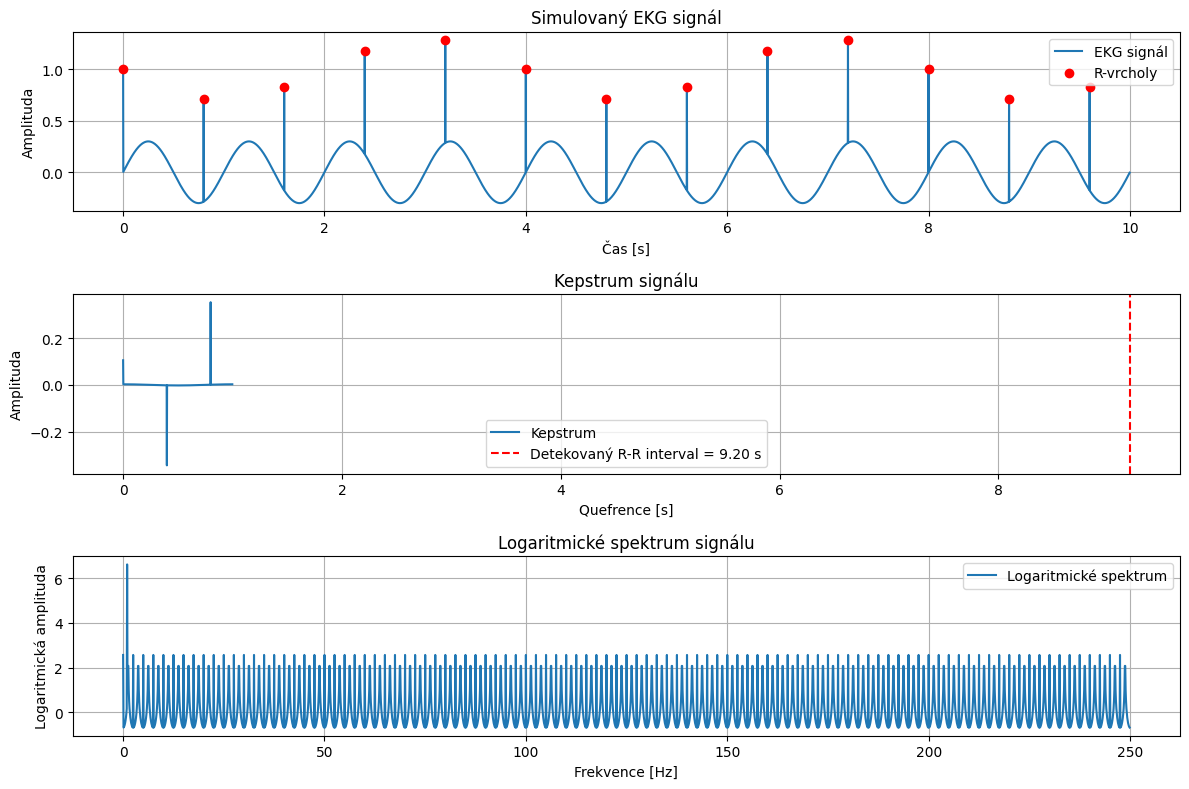

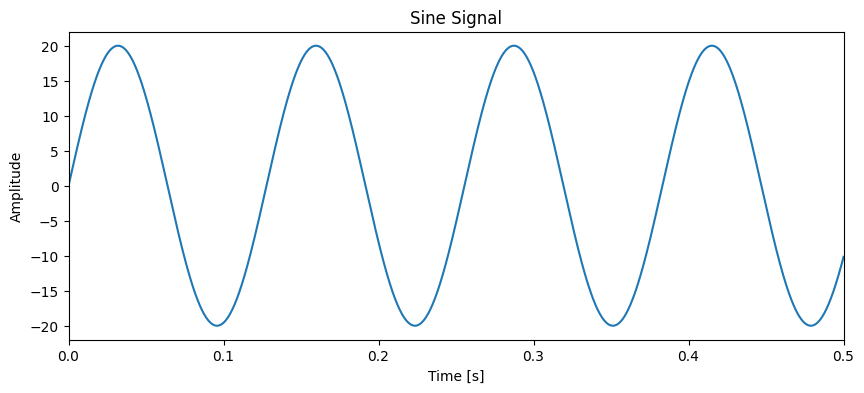

In [ ]:
#Kepstrální analýza
import numpy as np; import matplotlib.pyplot as plt; from scipy.signal import find_peaks
from scipy.io.wavfile import write; import sounddevice as sd
f_v = 500; t = np.linspace(0,10,f_v*10,endpoint=False) #10 s
hearth_rate = 60/75
r_peaks = np.zeros_like(t)
r_positions = np.arange(0,len(t),int(hearth_rate*f_v))
r_peaks[r_positions] = 1.0
ecg_signal = 0.3*np.sin(2*np.pi*1*t)+r_peaks
#kepstrum
ecg_fft = np.fft.fft(ecg_signal)  # Fourierova transformace signálu
log_magnitude = np.log(np.abs(ecg_fft) + 1e-10)  # Logaritmické spektrum
cepstrum = np.fft.ifft(log_magnitude).real  # Inverzní Fourierova transformace logaritmického spektra
# Detekce R-R intervalu z kepstra
quefrency = np.arange(len(cepstrum))/f_v  # "Časová osa" v kepstrální oblasti
rr_interval_idx = np.argmax(cepstrum[f_v // 2:]) + f_v // 2  # Největší hodnota v oblasti R-R
rr_interval = quefrency[rr_interval_idx]  # R-R interval v sekundách

plt.figure(figsize=(12, 8))
# Původní EKG signál
plt.subplot(3, 1, 1)
plt.plot(t, ecg_signal, label='EKG signál')
plt.scatter(t[r_positions], ecg_signal[r_positions], color='red', label='R-vrcholy', zorder=5)
plt.xlabel('Čas [s]');plt.ylabel('Amplituda');plt.title('Simulovaný EKG signál');plt.legend();plt.grid()
# Kepstrum
plt.subplot(3, 1, 2)
plt.plot(quefrency[:f_v], cepstrum[:f_v], label='Kepstrum')
plt.axvline(rr_interval, color='red', linestyle='--', label=f'Detekovaný R-R interval = {rr_interval:.2f} s')
plt.xlabel('Quefrence [s]'); plt.ylabel('Amplituda'); plt.title('Kepstrum signálu');plt.legend();plt.grid()
# Logaritmické spektrum
plt.subplot(3, 1, 3);frequencies = np.fft.fftfreq(len(ecg_signal), d=1/f_v)
plt.plot(frequencies[:len(ecg_signal)//2], log_magnitude[:len(ecg_signal)//2], label='Logaritmické spektrum')
plt.xlabel('Frekvence [Hz]');plt.ylabel('Logaritmická amplituda');plt.title('Logaritmické spektrum signálu');plt.legend();plt.grid()
plt.tight_layout();plt.show()

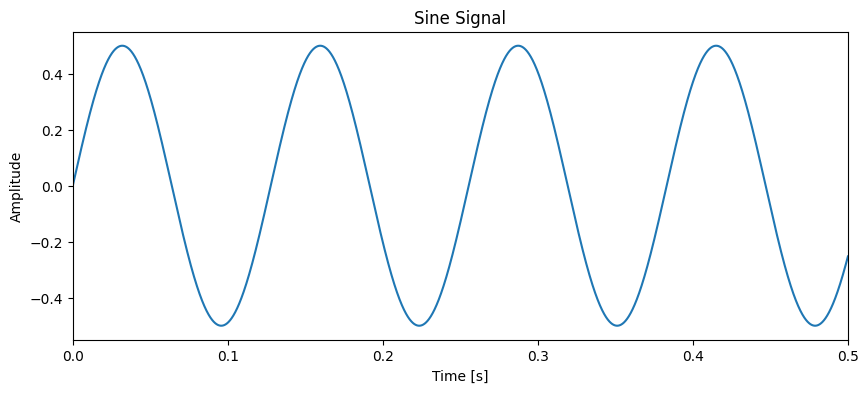

In [1]:
import numpy as np; import matplotlib.pyplot as plt; from scipy.io.wavfile import write; import sounddevice as sd
duration = 60; f=7.83; f_vz=10000
t = np.linspace(0,duration,int(f_vz*duration),endpoint=False)
signal = 0.5*np.sin(2*np.pi*f*t) 
carrier_freq = 110  # Nosná frekvence
modulated_signal = signal * np.sin(2 * np.pi * carrier_freq * t)
zesileny_signal = modulated_signal*5 #zesílení 
audio = np.clip(zesileny_signal, -1, 1) #aby to nebylo tak vysoky
plt.figure(figsize=(10, 4))
plt.plot(t, signal, label='Schuman');plt.xlabel('Time [s]');plt.ylabel('Amplitude');plt.title('Sine Signal')
plt.xlim(0, 0.5)
#sd.play(signal,samplerate=f_vz)
#sd.wait()
write("schumann.wav", f_vz, (audio*32767).astype(np.int16))